# eKYC CCCD Detection — KerasCV YOLO v8 → TFLite

Pipeline **pure TensorFlow/Keras** — không dùng TF OD API (broken trên Colab 2025).

| Thành phần | Công nghệ |
|-----------|----------|
| Training | `keras_cv.models.YOLOV8Detector` + `tf.data` |
| Backbone | YOLOv8-S pretrained COCO |
| Export | `model.save()` → SavedModel |
| TFLite | fp16 + int8 với `SELECT_TF_OPS` |

**Lớp nhận diện:** `bottom_left` · `bottom_right` · `image_person` · `top_left` · `top_right`

> Thời gian train: ~1 giờ (100 epochs, GPU T4)

In [1]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout[:500] if r.returncode == 0 else 'GPU not found — Runtime > Change runtime type > GPU')

Tue Apr 28 05:48:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


---
## Buoc 1: Cai dat

`keras-cv` la thu vien Computer Vision chinh thuc cua Keras/Google, ho tro:
- YOLO v8 Detector (anchor-free, hien dai)
- Data augmentation (mosaic, mixup, random flip...)
- Tuong thich Keras 3 + TF 2.16+

In [2]:
%%capture
!pip install -q keras-cv
!pip install -q Pillow tqdm opencv-python-headless matplotlib

In [3]:
import tensorflow as tf
import keras_cv
import keras
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'KerasCV    : {keras_cv.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
Keras      : 3.13.2
KerasCV    : 0.9.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Buoc 2: Cau hinh

**Chi chinh tai day truoc khi chay toan bo notebook.**

In [4]:
import os

# === CLASSES ===
CLASSES      = ['bottom_left', 'bottom_right', 'image_person', 'top_left', 'top_right']
NUM_CLASSES  = len(CLASSES)

# === MODEL ===
IMAGE_SIZE   = 320        # 320 hoac 416; 320 nhanh hon tren mobile
BATCH_SIZE   = 8          # giam xuong 4 neu OOM
EPOCHS       = 100        # so epochs train
LR           = 1e-3       # learning rate ban dau (cosine decay)

# Backbone preset — xem them: keras_cv.models.YOLOV8Backbone.presets
# yolo_v8_xs: nho nhat (~3MB tflite)   yolo_v8_s: can bang tot nhat
BACKBONE_PRESET = 'yolo_v8_s_backbone_coco'   # pretrained tren COCO

# === DUONG DAN ===
WORK_DIR       = '/content/ekyc_tf'
DATA_DIR       = f'{WORK_DIR}/data'
CKPT_DIR       = f'{WORK_DIR}/checkpoints'
SAVED_MODEL_DIR= f'{WORK_DIR}/saved_model'
TFLITE_DIR     = f'{WORK_DIR}/tflite'
DRIVE_DIR      = '/content/drive/MyDrive/ekyc_cccd'
SAVE_TO_DRIVE  = True

for d in [DATA_DIR, f'{DATA_DIR}/images/train', f'{DATA_DIR}/images/val',
          f'{DATA_DIR}/labels/train', f'{DATA_DIR}/labels/val',
          CKPT_DIR, SAVED_MODEL_DIR, TFLITE_DIR]:
    os.makedirs(d, exist_ok=True)

print('Cau hinh OK')
print(f'  Classes   : {CLASSES}')
print(f'  Backbone  : {BACKBONE_PRESET}')
print(f'  ImageSize : {IMAGE_SIZE}x{IMAGE_SIZE}')

Cau hinh OK
  Classes   : ['bottom_left', 'bottom_right', 'image_person', 'top_left', 'top_right']
  Backbone  : yolo_v8_s_backbone_coco
  ImageSize : 320x320


---
## Buoc 3: Upload Dataset

Cau truc can co:
```
data/
├── images/train/*.jpg
├── images/val/*.jpg
├── labels/train/*.txt   (YOLO format: class cx cy w h)
└── labels/val/*.txt
```

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# === CACH A: Upload ZIP tu may tinh ===
import zipfile
from google.colab import files

print('Chon file ZIP chua dataset...')
uploaded = files.upload()
for fname in uploaded:
    zip_path = f'/tmp/{fname}'
    with open(zip_path, 'wb') as f:
        f.write(uploaded[fname])
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(WORK_DIR)
    os.remove(zip_path)
    print(f'Giai nen xong -> {WORK_DIR}')

Chon file ZIP chua dataset...


Saving data.zip to data.zip
Giai nen xong -> /content/ekyc_tf


In [7]:
# === CACH B: Copy tu Google Drive ===
import shutil
DRIVE_DATASET = f'{DRIVE_DIR}/dataset'
if os.path.isdir(DRIVE_DATASET):
    shutil.copytree(f'{DRIVE_DATASET}/images', f'{DATA_DIR}/images', dirs_exist_ok=True)
    shutil.copytree(f'{DRIVE_DATASET}/labels', f'{DATA_DIR}/labels', dirs_exist_ok=True)
    print(f'Da copy tu {DRIVE_DATASET}')
else:
    print(f'Khong tim thay {DRIVE_DATASET} — dung Cach A')

Khong tim thay /content/drive/MyDrive/ekyc_cccd/dataset — dung Cach A


In [8]:
# Kiem tra dataset
import glob
train_imgs = glob.glob(f'{DATA_DIR}/images/train/*.jpg') + glob.glob(f'{DATA_DIR}/images/train/*.png')
val_imgs   = glob.glob(f'{DATA_DIR}/images/val/*.jpg')   + glob.glob(f'{DATA_DIR}/images/val/*.png')
train_lbls = glob.glob(f'{DATA_DIR}/labels/train/*.txt')
val_lbls   = glob.glob(f'{DATA_DIR}/labels/val/*.txt')

print(f'Train : {len(train_imgs)} anh | {len(train_lbls)} nhan')
print(f'Val   : {len(val_imgs)} anh | {len(val_lbls)} nhan')

if train_imgs and train_lbls:
    print('\nDataset hop le')
    with open(train_lbls[0]) as f:
        for line in f.readlines()[:2]:
            p = line.strip().split()
            print(f'  class={p[0]}({CLASSES[int(p[0])]}) cx={p[1]} cy={p[2]} w={p[3]} h={p[4]}')
else:
    print('Chua co du lieu — hay upload dataset truoc!')

Train : 371 anh | 371 nhan
Val   : 58 anh | 58 nhan

Dataset hop le
  class=3(top_left) cx=0.1796875 cy=0.14609375 w=0.0515625 h=0.075
  class=4(top_right) cx=0.85546875 cy=0.140625 w=0.071875 h=0.0625


---
## Buoc 4: Xay dung tf.data Pipeline

KerasCV YOLO nhan dau vao la:
- **Image**: `float32` tensor `[H, W, 3]` gia tri `[0, 1]`
- **Bounding boxes**: dict `{"boxes": RaggedTensor [N,4], "classes": RaggedTensor [N]}`
  - Format `rel_xyxy`: `[x1, y1, x2, y2]` normalized `[0, 1]`

YOLO label (cx, cy, w, h) → rel_xyxy (x1, y1, x2, y2):
```
x1 = cx - w/2,  x2 = cx + w/2
y1 = cy - h/2,  y2 = cy + h/2
```

`ragged_batch` giu nguyen so hop tuy y moi anh ma khong can padding.

In [9]:
import numpy as np
from PIL import Image as PILImage


def load_yolo_sample(img_path: str, lbl_dir: str, image_size: int):
    """Doc 1 anh + nhan YOLO → (image_arr, boxes_arr, classes_arr)."""
    stem     = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(lbl_dir, stem + '.txt')

    img = PILImage.open(img_path).convert('RGB').resize((image_size, image_size))
    img_arr = np.array(img, dtype=np.float32) / 255.0   # [H,W,3] in [0,1]

    boxes, classes = [], []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) != 5:
                    continue
                cls_id = int(p[0])
                cx, cy, bw, bh = map(float, p[1:])
                # YOLO center-wh -> corner rel_xyxy
                x1 = max(0.0, cx - bw / 2)
                y1 = max(0.0, cy - bh / 2)
                x2 = min(1.0, cx + bw / 2)
                y2 = min(1.0, cy + bh / 2)
                boxes.append([x1, y1, x2, y2])
                classes.append(float(cls_id))

    if boxes:
        boxes_arr   = np.array(boxes,   dtype=np.float32)
        classes_arr = np.array(classes, dtype=np.float32)
    else:
        boxes_arr   = np.zeros((0, 4), dtype=np.float32)
        classes_arr = np.zeros((0,),   dtype=np.float32)

    return img_arr, boxes_arr, classes_arr


def build_dataset(img_dir: str, lbl_dir: str, image_size: int,
                  batch_size: int, shuffle: bool = True):
    """Tao tf.data.Dataset voi ragged_batch cho KerasCV."""
    img_paths = sorted(
        glob.glob(f'{img_dir}/*.jpg') +
        glob.glob(f'{img_dir}/*.jpeg') +
        glob.glob(f'{img_dir}/*.png')
    )
    if not img_paths:
        raise ValueError(f'Khong co anh trong {img_dir}')

    def py_load(img_path_tensor):
        img, boxes, classes = load_yolo_sample(
            img_path_tensor.numpy().decode('utf-8'), lbl_dir, image_size
        )
        return img, boxes, classes

    def tf_load(img_path):
        img, boxes, classes = tf.py_function(
            py_load, [img_path], [tf.float32, tf.float32, tf.float32]
        )
        img.set_shape([image_size, image_size, 3])
        boxes.set_shape([None, 4])
        classes.set_shape([None])
        # KerasCV nhan bounding_boxes la dict
        return img, {'boxes': boxes, 'classes': classes}

    ds = tf.data.Dataset.from_tensor_slices(img_paths)
    if shuffle:
        ds = ds.shuffle(len(img_paths), reshuffle_each_iteration=True)
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    # ragged_batch: gop cac anh thanh batch, giu nguyen so box khac nhau
    ds = ds.ragged_batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, len(img_paths)


print('Building datasets...')
train_ds, n_train = build_dataset(
    f'{DATA_DIR}/images/train', f'{DATA_DIR}/labels/train',
    IMAGE_SIZE, BATCH_SIZE, shuffle=True
)
val_ds, n_val = build_dataset(
    f'{DATA_DIR}/images/val', f'{DATA_DIR}/labels/val',
    IMAGE_SIZE, BATCH_SIZE, shuffle=False
)
steps_per_epoch = max(1, n_train // BATCH_SIZE)
print(f'Train : {n_train} anh | {steps_per_epoch} steps/epoch')
print(f'Val   : {n_val} anh')

Building datasets...
Train : 371 anh | 46 steps/epoch
Val   : 58 anh


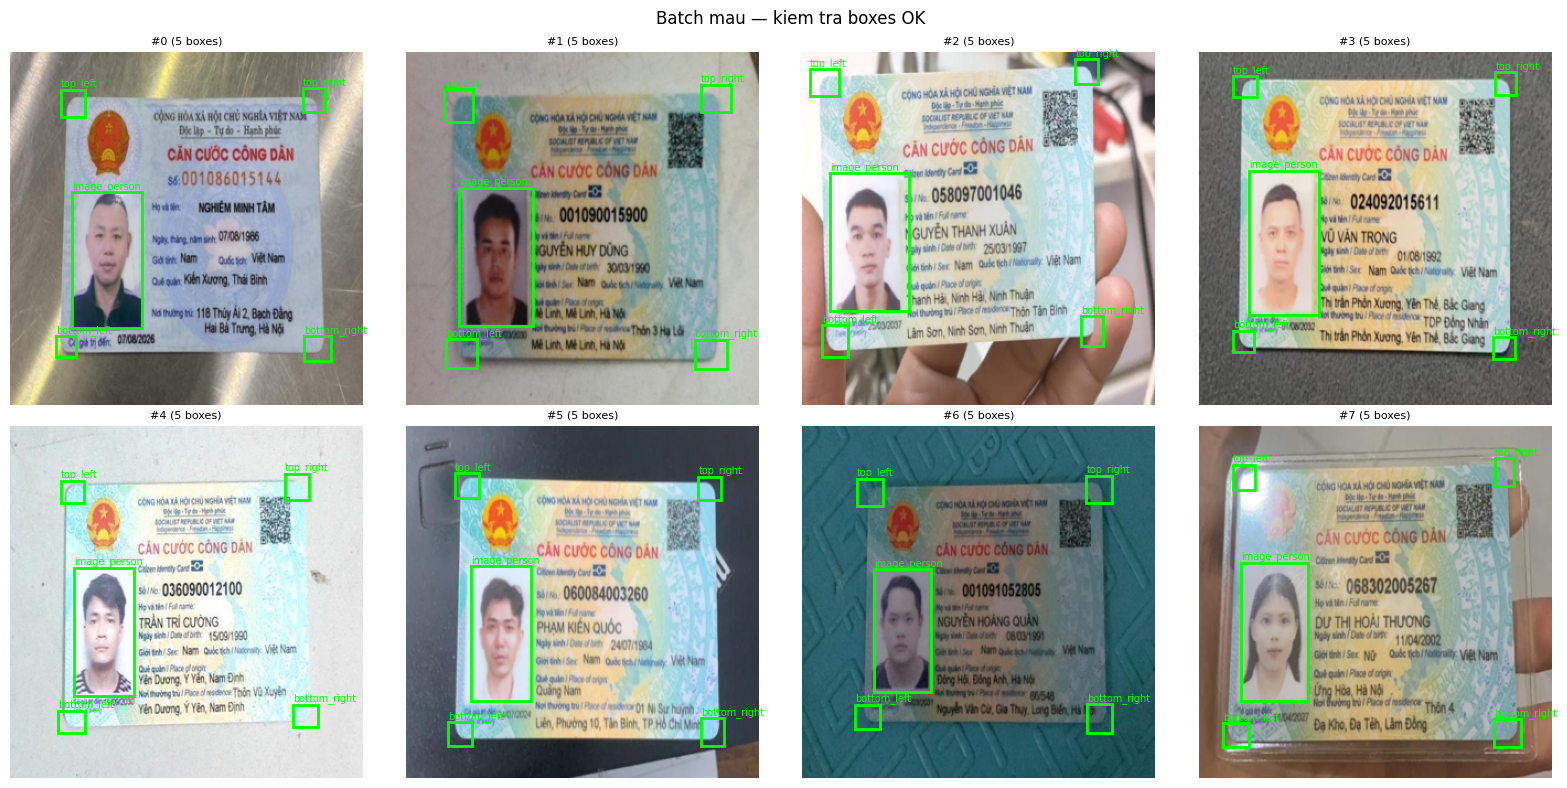

In [10]:
# Hien thi 1 batch mau de kiem tra pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as patches

for imgs, bboxes in train_ds.take(1):
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for idx, ax in enumerate(axes.flat):
        if idx >= imgs.shape[0]:
            ax.axis('off'); continue
        img = imgs[idx].numpy()
        ax.imshow(img)
        H, W = img.shape[:2]
        boxes   = bboxes['boxes'][idx].numpy()   if hasattr(bboxes['boxes'][idx], 'numpy') else bboxes['boxes'][idx]
        classes = bboxes['classes'][idx].numpy() if hasattr(bboxes['classes'][idx], 'numpy') else bboxes['classes'][idx]
        for box, cls in zip(boxes, classes):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1*W, y1*H), (x2-x1)*W, (y2-y1)*H,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1*W, y1*H-4, CLASSES[int(cls)], color='lime', fontsize=7)
        ax.axis('off')
        ax.set_title(f'#{idx} ({len(boxes)} boxes)', fontsize=8)
    plt.suptitle('Batch mau — kiem tra boxes OK', fontsize=12)
    plt.tight_layout()
    plt.show()
    break

---
## Buoc 5: Xay dung Model YOLOV8Detector

**Tai sao YOLO v8?**
- Anchor-free → don gian hon SSD, it tham so hon
- Backbone YOLOv8-S pretrained COCO → hoi tu nhanh tren 462 anh
- FPN (Feature Pyramid) → phat hien tot goc nho cua the CCCD

**Tai sao khong dung SSD MobileNetV2 (TF OD API)?**
- TF OD API training scripts (`model_main_tf2.py`) phu thuoc `tf.estimator`
- `tf.estimator` bi xoa hoan toan khoi TF 2.16+ — khong co patch
- KerasCV hoat dong tren Keras 3 + TF 2.16+ hoac moi hon

In [11]:
# Tai backbone pretrained COCO
print(f'Dang tai backbone: {BACKBONE_PRESET} ...')
backbone = keras_cv.models.YOLOV8Backbone.from_preset(BACKBONE_PRESET)

# Build detector
model = keras_cv.models.YOLOV8Detector(
    num_classes       = NUM_CLASSES,
    bounding_box_format = 'rel_xyxy',   # normalized [x1,y1,x2,y2] trong [0,1]
    backbone          = backbone,
    fpn_depth         = 1,              # nhe hon cho model nho
)

print('Model da xay xong')
print(f'  num_classes          : {NUM_CLASSES}')
print(f'  bounding_box_format  : rel_xyxy')
print(f'  backbone             : {BACKBONE_PRESET}')

Dang tai backbone: yolo_v8_s_backbone_coco ...


100%|██████████| 646/646 [00:00<00:00, 1.69MB/s]


Model da xay xong
  num_classes          : 5
  bounding_box_format  : rel_xyxy
  backbone             : yolo_v8_s_backbone_coco


In [12]:
# Learning rate: cosine decay tu LR xuong LR*0.01 trong EPOCHS epochs
total_steps = EPOCHS * steps_per_epoch
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = LR,
    decay_steps           = total_steps,
    alpha                 = LR * 0.01,   # LR cuoi = 1% LR ban dau
)

# Compile — box_loss va classification_loss la ten chuan cua KerasCV
model.compile(
    optimizer           = keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9),
    box_loss            = 'ciou',              # Complete IoU — tot hon GIoU cho detection
    classification_loss = 'binary_crossentropy',
    jit_compile         = False                # Tắt JIT compilation để tránh lỗi với RaggedTensor
)

# Chay 1 batch de khoi tao weights
for imgs, bboxes in train_ds.take(1):
    _ = model(imgs, training=False)

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
total     = sum(tf.size(v).numpy() for v in model.variables)
print(f'Tham so co the train : {trainable:,}')
print(f'Tong tham so         : {total:,}')

Tham so co the train : 12,777,455
Tong tham so         : 12,799,023


---
## Buoc 6: Huan luyen

- `ModelCheckpoint` luu best model theo `val_loss`
- `EarlyStopping` dung khi val_loss khong giam sau 15 epochs
- `ReduceLROnPlateau` giam LR x0.5 neu plateau
- `TensorBoard` log de theo doi

> Chay TensorBoard song song: `%tensorboard --logdir /content/ekyc_tf/checkpoints`

In [13]:
BEST_MODEL_PATH = f'{CKPT_DIR}/best_model.keras'

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath        = BEST_MODEL_PATH,
        monitor         = 'val_loss',
        save_best_only  = True,
        verbose         = 1,
    ),
    keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1,
    ),
    # Removed ReduceLROnPlateau as it conflicts with LearningRateSchedule
    keras.callbacks.TensorBoard(log_dir=CKPT_DIR, histogram_freq=0),
]

print(f'Bat dau train {EPOCHS} epochs...')
print(f'Steps/epoch : {steps_per_epoch}')
print(f'Best model  : {BEST_MODEL_PATH}')
print()

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

Bat dau train 100 epochs...
Steps/epoch : 46
Best model  : /content/ekyc_tf/checkpoints/best_model.keras

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - box_loss: 3.4001 - class_loss: 77.2537 - loss: 80.6621
Epoch 1: val_loss improved from None to 10.03790, saving model to /content/ekyc_tf/checkpoints/best_model.keras

Epoch 1: finished saving model to /content/ekyc_tf/checkpoints/best_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 59s 404ms/step - box_loss: 2.6119 - class_loss: 29.8986 - loss: 32.9007 - val_box_loss: 3.9062 - val_class_loss: 5.9134 - val_loss: 10.0379
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - box_loss: 1.5876 - class_loss: 1.5454 - loss: 3.1333
Epoch 2: val_loss improved from 10.03790 to 3.97059, saving model to /content/ekyc_tf/checkpoints/best_model.keras

Epoch 2: finished saving model to /content/ekyc_tf/checkpoints/best_model.keras
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 265ms/step - box_loss: 1.5241 - class_loss: 1.2713 - loss: 2.8089 - val_box_loss: 2.3078 

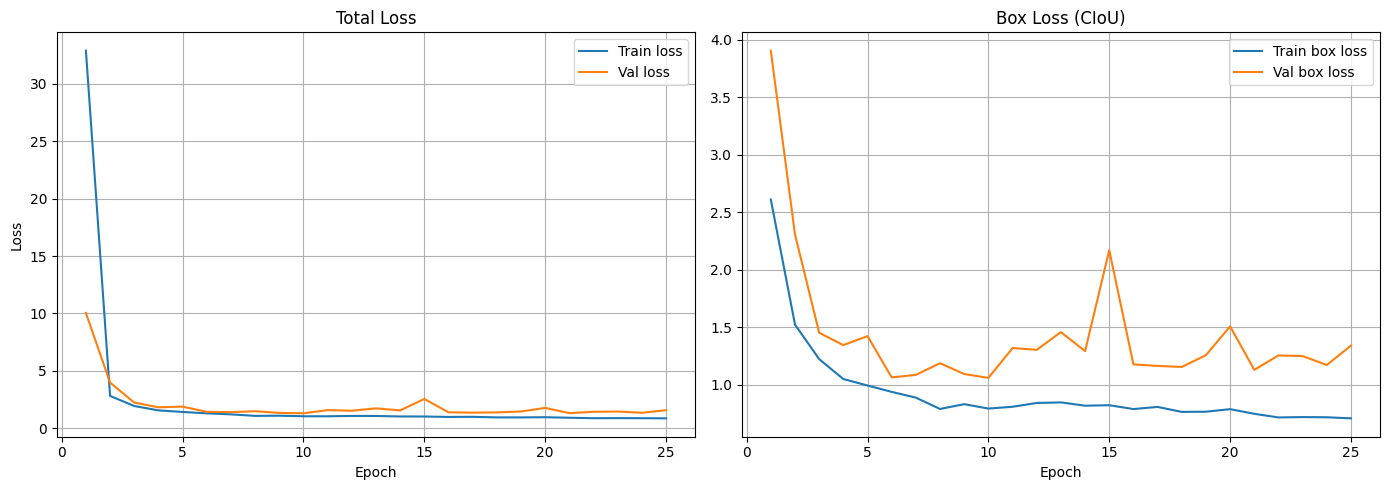

Best val_loss: 1.2935 (epoch 10)


In [46]:
# Hien thi bieu do loss
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, hist['loss'],     label='Train loss')
axes[0].plot(epochs_range, hist['val_loss'], label='Val loss')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

if 'box_loss' in hist:
    axes[1].plot(epochs_range, hist['box_loss'],     label='Train box loss')
    axes[1].plot(epochs_range, hist['val_box_loss'], label='Val box loss')
    axes[1].set_title('Box Loss (CIoU)')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/training_curves.png', dpi=120)
plt.show()
print(f'Best val_loss: {min(hist["val_loss"]):.4f} (epoch {hist["val_loss"].index(min(hist["val_loss"]))+1})')

In [15]:
# Load lai best model (EarlyStopping co the da restore weights roi, nhung chac an)
if os.path.isfile(BEST_MODEL_PATH):
    model = keras.models.load_model(BEST_MODEL_PATH)
    print(f'Loaded best model: {BEST_MODEL_PATH}')
else:
    print('Dang dung model cuoi cung (EarlyStopping da restore weights)')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Loaded best model: /content/ekyc_tf/checkpoints/best_model.keras


---
## Buoc 7: Export sang SavedModel

Luu model theo dinh dang SavedModel cua TF2:
- Chua toan bo kien truc + weights + NMS decoder
- Co the load lai bang `tf.saved_model.load()` de chay inference tren server
- La buoc trung gian de chuyen sang TFLite

In [48]:
print(f'Dang luu SavedModel -> {SAVED_MODEL_DIR} ...')
# Export the model with the prediction decoder (NMS) integrated
model.export(SAVED_MODEL_DIR)

print('Luu xong! (Model + Decoder)')

# Kiem tra
total_bytes = sum(
    os.path.getsize(os.path.join(r, f))
    for r, _, fs in os.walk(SAVED_MODEL_DIR) for f in fs
)
print(f'Kich thuoc SavedModel : {total_bytes/1024/1024:.1f} MB')

Dang luu SavedModel -> /content/ekyc_tf/saved_model ...
Saved artifact at '/content/ekyc_tf/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='keras_tensor_417')
Output Type:
  Dict[['boxes', TensorSpec(shape=(None, None, 64), dtype=tf.float32, name=None)], ['classes', TensorSpec(shape=(None, None, 5), dtype=tf.float32, name=None)]]
Captures:
  136342197379600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197380752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197381136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197378832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197382864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197380368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197379408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136342197379792: TensorSpec(shape=(), dtype=tf.re

---
## Buoc 8: Chuyen doi sang TFLite

KerasCV YOLO dung `tf.image.combined_non_max_suppression` (NMS) — op nay
khong nam trong `TFLITE_BUILTINS` chuan. Giai phap:

| Phuong phap | Kich thuoc | On dinh | Dung khi |
|-------------|-----------|---------|----------|
| `TFLITE_BUILTINS` + `SELECT_TF_OPS` | lon hon | cao | dev + Android Flex Delegate |
| Tach NMS ra khoi model | nho hon | cao | production mobile |

Notebook nay dung **SELECT_TF_OPS** — don gian, chay duoc tren Android/iOS
voi Flex Delegate (`TfLiteDelegate`).

In [50]:
import tensorflow as tf
from PIL import Image as PILImage
import numpy as np
import os
import glob

# Load the combined SavedModel
loaded_model = tf.saved_model.load(SAVED_MODEL_DIR)
serving_fn = loaded_model.signatures['serve']

# Identify the exact input key required by the signature (e.g., 'keras_tensor_417')
input_key = list(serving_fn.structured_input_signature[1].keys())[0]
print(f'Detected signature input key: {input_key}')

# Define a concrete function with a fixed input shape for TFLite conversion
@tf.function(input_signature=[
    tf.TensorSpec(shape=[1, IMAGE_SIZE, IMAGE_SIZE, 3], dtype=tf.float32, name='input_tensor')
])
def serving_with_fixed_input_and_nms(input_tensor):
    # Pass input using the detected internal key
    kwargs = {input_key: input_tensor}
    return serving_fn(**kwargs)

# Get the concrete function to pass to the TFLite converter
concrete_func_for_tflite = serving_with_fixed_input_and_nms.get_concrete_function()

# --- fp32: khong quantize (baseline) ---
print('[1/3] Converting fp32 ...')
conv = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func_for_tflite])
conv.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
fp32_bytes = conv.convert()
fp32_path  = f'{TFLITE_DIR}/model_fp32.tflite'
with open(fp32_path, 'wb') as f:
    f.write(fp32_bytes)
print(f'  {fp32_path}  ({os.path.getsize(fp32_path)/1024/1024:.1f} MB)')

# --- fp16: quantize weights sang float16 (~2x nho hon) ---
print("\n[2/3] Converting fp16 ...")
conv = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func_for_tflite])
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
conv.target_spec.supported_ops   = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
fp16_bytes = conv.convert()
fp16_path  = f'{TFLITE_DIR}/model_fp16.tflite'
with open(fp16_path, 'wb') as f:
    f.write(fp16_bytes)
print(f'  {fp16_path}  ({os.path.getsize(fp16_path)/1024/1024:.1f} MB)')

Detected signature input key: keras_tensor_417


[1/3] Converting fp32 ...


  /content/ekyc_tf/tflite/model_fp32.tflite  (48.8 MB)

[2/3] Converting fp16 ...
  /content/ekyc_tf/tflite/model_fp16.tflite  (24.5 MB)


In [42]:
# --- int8: full integer quantization (can anh hieu chinh) ---
print('[3/3] int8 (mat ~3-5 phut)...')

calib_paths = (
    glob.glob(f'{DATA_DIR}/images/train/*.jpg') +
    glob.glob(f'{DATA_DIR}/images/train/*.png')
)[:100]

def representative_dataset():
    for path in calib_paths:
        img = PILImage.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        arr = np.array(img, dtype=np.float32)[np.newaxis] / 255.0  # [1,H,W,3]
        yield [arr]

conv = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func_for_tflite])
conv.optimizations             = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset    = representative_dataset
conv.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
conv.inference_input_type  = tf.float32
conv.inference_output_type = tf.float32

int8_bytes = conv.convert()
int8_path  = f'{TFLITE_DIR}/model_int8.tflite'
with open(int8_path, 'wb') as f:
    f.write(int8_bytes)
print(f'  {int8_path}  ({os.path.getsize(int8_path)/1024/1024:.1f} MB)')

[3/3] int8 (mat ~3-5 phut)...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  /content/ekyc_tf/tflite/model_int8.tflite  (12.6 MB)


In [43]:
# So sanh kich thuoc
sizes = {
    'SavedModel'   : sum(os.path.getsize(os.path.join(r,f)) for r,_,fs in os.walk(SAVED_MODEL_DIR) for f in fs),
    'TFLite fp32'  : os.path.getsize(fp32_path),
    'TFLite fp16'  : os.path.getsize(fp16_path),
    'TFLite int8'  : os.path.getsize(int8_path),
}
print(f'\n{"Model":<18} {"Size":>10}')
print('-' * 30)
for name, size in sizes.items():
    bar = 'X' * int(size / sizes['SavedModel'] * 25)
    print(f'{name:<18} {size/1024/1024:>7.1f} MB  {bar}')


Model                    Size
------------------------------
SavedModel           100.1 MB  XXXXXXXXXXXXXXXXXXXXXXXXX
TFLite fp32           48.8 MB  XXXXXXXXXXXX
TFLite fp16           24.5 MB  XXXXXX
TFLite int8           12.6 MB  XXX


---
## Buoc 9: Test Inference TFLite

KerasCV YOLOV8Detector output sau khi decode (qua SavedModel/TFLite):
- `boxes`           : `[B, N, 4]` format rel_xyxy
- `confidence`      : `[B, N]` score tong hop
- `classes`         : `[B, N]` class id (float)
- `num_detections`  : `[B]` so hop sau NMS

Voi TFLite, cac output tensor duoc tra ve theo ten. Code ben duoi tu dong
nhan dien tensor nao la boxes/scores/classes bang cach kiem tra shape.

In [57]:
import time
import matplotlib.patches as mpatches
import tensorflow as tf
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt

COLORS = ['#00FF00','#FF4444','#4488FF','#FF8800','#CC44FF']
SCORE_THRESH = 0.35

def decode_dfl(dfl_preds, image_size=320, reg_max=16):
    """Giải mã YOLOv8 DFL (Dist-to-BBox) thành tọa độ normalized xyxy."""
    strides = [8, 16, 32]
    grid_sizes = [(image_size // s, image_size // s) for s in strides]

    anchors = []
    for stride, (gh, gw) in zip(strides, grid_sizes):
        for y in range(gh):
            for x in range(gw):
                anchors.append([x + 0.5, y + 0.5, stride])
    anchors = np.array(anchors)

    def softmax(x):
        e = np.exp(x - x.max(axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    dfl = dfl_preds.reshape(-1, 4, reg_max)
    dfl = softmax(dfl)
    bins = np.arange(reg_max, dtype=np.float32)
    dist = (dfl * bins).sum(axis=-1)

    lt = dist[:, :2]
    rb = dist[:, 2:]

    x1 = (anchors[:, 0] - lt[:, 0]) * anchors[:, 2] / image_size
    y1 = (anchors[:, 1] - lt[:, 1]) * anchors[:, 2] / image_size
    x2 = (anchors[:, 0] + rb[:, 0]) * anchors[:, 2] / image_size
    y2 = (anchors[:, 1] + rb[:, 1]) * anchors[:, 2] / image_size

    return np.stack([x1, y1, x2, y2], axis=1)

def simple_nms(boxes, scores, iou_thr=0.45):
    """Manual Non-Maximum Suppression."""
    if len(boxes) == 0: return []
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas = (x2-x1) * (y2-y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, (xx2-xx1)) * np.maximum(0, (yy2-yy1))
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        order = order[1:][iou <= iou_thr]
    return keep

def run_tflite(model_path: str, img_path: str, score_thresh: float = SCORE_THRESH):
    interp = tf.lite.Interpreter(model_path=model_path, num_threads=4)
    interp.allocate_tensors()

    in_det = interp.get_input_details()[0]
    out_dets = interp.get_output_details()

    img_orig = PILImage.open(img_path).convert('RGB')
    W0, H0 = img_orig.size
    img_res = img_orig.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_arr = np.array(img_res, dtype=np.float32)[np.newaxis] / 255.0

    interp.set_tensor(in_det['index'], img_arr)
    t0 = time.perf_counter()
    interp.invoke()
    ms = (time.perf_counter() - t0) * 1000

    # Map outputs by shape
    # Identity typically [1, 2100, 64], Identity_1 typically [1, 2100, 5]
    outputs = {d['shape'][2]: interp.get_tensor(d['index'])[0] for d in out_dets}
    raw_dfl = outputs[64]
    raw_cls = outputs[5]

    # Decode scores and classes
    scores_all = raw_cls.max(axis=1)
    classes_all = raw_cls.argmax(axis=1)
    boxes_all = decode_dfl(raw_dfl, image_size=IMAGE_SIZE)

    # Threshold filter
    mask = scores_all >= score_thresh
    boxes = boxes_all[mask]
    scores = scores_all[mask]
    classes = classes_all[mask]

    # NMS
    keep = simple_nms(boxes, scores)
    boxes, scores, classes = boxes[keep], scores[keep], classes[keep]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_orig)

    for i in range(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        cls_id = int(classes[i])
        color = COLORS[cls_id % len(COLORS)]
        rect = mpatches.Rectangle((x1*W0, y1*H0), (x2-x1)*W0, (y2-y1)*H0, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1*W0, y1*H0-5, f"{CLASSES[cls_id]} {scores[i]:.2f}", color=color, fontsize=10, bbox=dict(facecolor='black', alpha=0.5))

    ax.set_title(f'TFLite Manual Decode | {ms:.1f}ms | {len(boxes)} detections')
    ax.axis('off')
    plt.show()

Test image: /content/ekyc_tf/data/images/val/image710_jpg.rf.2600be3e3a08703e50cc0d39846e6719.jpg

--- Running inference with fp16 TFLite model ---


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


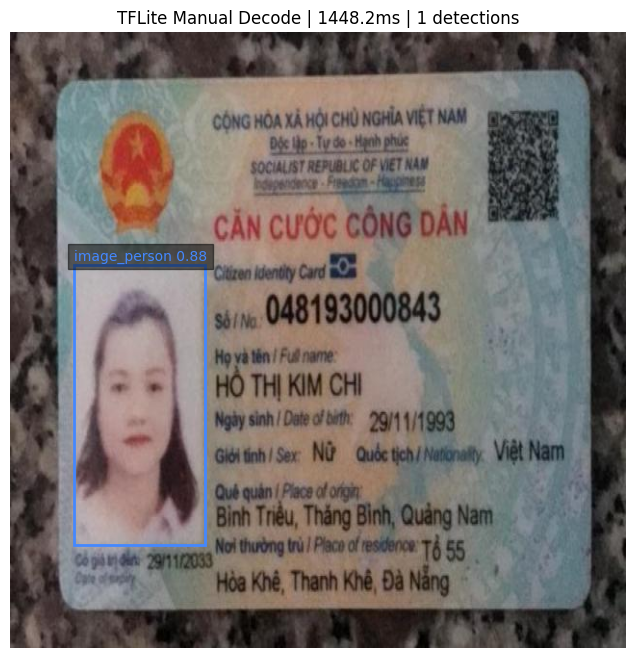

In [58]:
# Test tren anh val
test_imgs = (
    glob.glob(f'{DATA_DIR}/images/val/*.jpg') +
    glob.glob(f'{DATA_DIR}/images/val/*.png')
)

if test_imgs:
    test_img = test_imgs[0]
    print(f'Test image: {test_img}\n')
    print('--- Running inference with fp16 TFLite model ---')
    run_tflite(fp16_path, test_img, score_thresh=0.5)
else:
    print('Khong co anh val de test.')

Saving test.jpg to test.jpg

Test voi: test.jpg


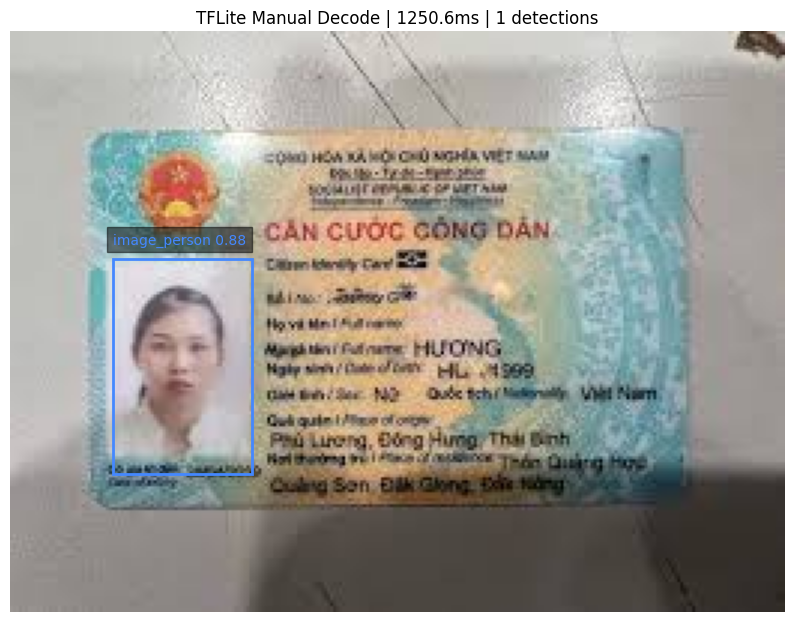

In [59]:
# Upload anh CCCD tu may tinh de test nhanh
from google.colab import files
uploaded_test = files.upload()
for fname in uploaded_test:
    p = f'/tmp/{fname}'
    with open(p, 'wb') as f:
        f.write(uploaded_test[fname])
    print(f'\nTest voi: {fname}')
    run_tflite(fp16_path, p, score_thresh=0.25)

---
## Buoc 10: Luu ve Drive & Download

In [23]:
import shutil, zipfile

if SAVE_TO_DRIVE:
    drive_tflite = f'{DRIVE_DIR}/tflite'
    os.makedirs(drive_tflite, exist_ok=True)
    for fname in ['model_fp32.tflite', 'model_fp16.tflite', 'model_int8.tflite']:
        src = f'{TFLITE_DIR}/{fname}'
        if os.path.isfile(src):
            shutil.copy2(src, f'{drive_tflite}/{fname}')
            print(f'Saved -> {drive_tflite}/{fname}')
    # Luu anh bieu do
    curve_src = f'{CKPT_DIR}/training_curves.png'
    if os.path.isfile(curve_src):
        shutil.copy2(curve_src, f'{DRIVE_DIR}/training_curves.png')
    print(f'\nDa luu vao Drive: {drive_tflite}')

Saved -> /content/drive/MyDrive/ekyc_cccd/tflite/model_fp32.tflite
Saved -> /content/drive/MyDrive/ekyc_cccd/tflite/model_fp16.tflite
Saved -> /content/drive/MyDrive/ekyc_cccd/tflite/model_int8.tflite

Da luu vao Drive: /content/drive/MyDrive/ekyc_cccd/tflite


In [24]:
# Download ZIP cac TFLite model ve may
from google.colab import files

zip_path = '/tmp/ekyc_tflite_keras.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in ['model_fp16.tflite', 'model_int8.tflite', 'model_fp32.tflite']:
        src = f'{TFLITE_DIR}/{fname}'
        if os.path.isfile(src):
            zf.write(src, fname)
            print(f'  + {fname} ({os.path.getsize(src)/1024/1024:.1f} MB)')
    # Them file class names de de su dung trong app
    classes_txt = '\n'.join(CLASSES)
    zf.writestr('classes.txt', classes_txt)
    print('  + classes.txt')

print(f'\nZIP: {os.path.getsize(zip_path)/1024/1024:.1f} MB')
files.download(zip_path)

  + model_fp16.tflite (24.5 MB)
  + model_int8.tflite (12.6 MB)
  + model_fp32.tflite (48.8 MB)
  + classes.txt

ZIP: 79.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Tong ket Pipeline

```
YOLO Dataset (images/ + labels/)
        |
        v  Buoc 4: tf.data + ragged_batch
   tf.data.Dataset (batches chua RaggedTensor boxes)
        |
        v  Buoc 5-6: KerasCV YOLOV8Detector.fit()
   Trained model (.keras)
        |
        v  Buoc 7: model.save()
   SavedModel/
        |
        +----> model_fp32.tflite  (full precision)
        +----> model_fp16.tflite  (half precision, ~2x nho hon) <- khuyen nghi
        +----> model_int8.tflite  (integer, nho nhat)
```

### Trien khai Android
```gradle
// Them Flex Delegate de chay SELECT_TF_OPS
implementation 'org.tensorflow:tensorflow-lite-select-tf-ops:+'
implementation 'org.tensorflow:tensorflow-lite:+'
```

### Cai thien accuracy
- Tang `EPOCHS` len 200 hoac 300
- Dung `yolo_v8_m_backbone_coco` (medium, chinh xac hon)
- Them data augmentation bang `keras_cv.layers.RandomFlip`, `RandomBrightness`...